#Nizam Shaikh - 24198170


# Lab: Credit Scoring Using AI Models


Aim of the Lab
This lab focuses on building and evaluating machine learning models to assess credit risk. By predicting whether a loan applicant is likely to default based on their financial and personal details we get hands on experience with the full data pipeline. This includes cleaning the data, extracting features, training the models and looking at how the algorithms actually make their decisions via their predicted metrics which is tying directly back to our class lectures.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Splitting
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

# Modeling & Evaluation
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

## Dataset Description
https://www.kaggle.com/datasets/varunchawla30/german-credit-data

In [2]:
# Load the dataset (Make sure the CSV file is in the same folder as your notebook)
!pip install -q kaggle
!kaggle datasets download -d varunchawla30/german-credit-data --unzip
df = pd.read_csv('german_credit_data.csv')

Dataset URL: https://www.kaggle.com/datasets/varunchawla30/german-credit-data
License(s): DbCL-1.0
100% 12.4k/12.4k [00:00<00:00, 23.6MB/s]



## Initial Data Exploration

Display the first few rows

Check dataset shape

Check column names

Check data types

Check missing values

Check class distribution

In [3]:
# Drop the 'Unnamed: 0' column if it exists (common in this specific dataset)
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Shape ---")
print(df.shape)

print("\n--- Column Names ---")
print(df.columns.tolist())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Class Distribution (Target Variable) ---")
# The target column in this dataset is typically named 'kredit'
print(df['kredit'].value_counts())

--- First 5 Rows ---


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1



--- Dataset Shape ---
(1000, 21)

--- Column Names ---
['laufkont', 'laufzeit', 'moral', 'verw', 'hoehe', 'sparkont', 'beszeit', 'rate', 'famges', 'buerge', 'wohnzeit', 'verm', 'alter', 'weitkred', 'wohn', 'bishkred', 'beruf', 'pers', 'telef', 'gastarb', 'kredit']

--- Data Types ---
laufkont    int64
laufzeit    int64
moral       int64
verw        int64
hoehe       int64
sparkont    int64
beszeit     int64
rate        int64
famges      int64
buerge      int64
wohnzeit    int64
verm        int64
alter       int64
weitkred    int64
wohn        int64
bishkred    int64
beruf       int64
pers        int64
telef       int64
gastarb     int64
kredit      int64
dtype: object

--- Missing Values ---
laufkont    0
laufzeit    0
moral       0
verw        0
hoehe       0
sparkont    0
beszeit     0
rate        0
famges      0
buerge      0
wohnzeit    0
verm        0
alter       0
weitkred    0
wohn        0
bishkred    0
beruf       0
pers        0
telef       0
gastarb     0
kredit      0
dtyp

## Handling Missing Values
I used median imputation for the numerical data to avoid skewing the results with outliers and filled missing categorical values with the mode  as its the most frequent category. Handling these gaps early on is crucial because most machine learning algorithms will throw errors if they encounter empty cells during training.

In [4]:
# Handle missing numerical values with Median
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Handle missing categorical values with Mode
for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify missing values are gone
print("Remaining missing values:\n", df.isnull().sum())

Remaining missing values:
 laufkont    0
laufzeit    0
moral       0
verw        0
hoehe       0
sparkont    0
beszeit     0
rate        0
famges      0
buerge      0
wohnzeit    0
verm        0
alter       0
weitkred    0
wohn        0
bishkred    0
beruf       0
pers        0
telef       0
gastarb     0
kredit      0
dtype: int64


/tmp/ipykernel_5683/3438688384.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


## Encoding Categorical Variables

Since machine learning models run on math they can't process text labels directly. I used One-hot encoding to transform categorical variables into binary dummy columns (0s and 1s). This ensures the model doesn't falsely assume a natural ranking or hierarchy between the different text categories.

In [8]:
# Separate target variable before encoding to keep it as a single column
target = df['kredit']
df_features = df.drop('kredit', axis=1)

# Apply One-Hot Encoding to the features
df_encoded = pd.get_dummies(df_features, drop_first=True)

# Add the target column back
df_encoded['kredit'] = target

display(df_encoded.head())

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


## Feature Scaling

I applied standardization to the numerical features so they all have a mean of zero and a similar spread. This step keeps variables with larger ranges (like credit amount) from completely overpowering smaller variables (like age or duration) during the training process.

In [11]:
# Identify numerical columns to scale using the actual names in the dataset
# 'alter' = Age, 'hoehe' = Credit amount, 'laufzeit' = Duration
num_cols = ['alter', 'hoehe', 'laufzeit']

scaler = StandardScaler()

# Scale only these numerical features within df_encoded
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Define df_scaled for subsequent cells
df_scaled = df_encoded.copy()

display(df_scaled.head())

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,-0.240857,4,2,-0.787657,1,2,4,2,1,...,2,-1.281573,3,1,1,3,2,1,2,1
1,1,-0.987573,4,0,-0.167384,1,3,2,3,1,...,1,0.040363,3,1,2,3,1,1,2,1
2,2,-0.738668,2,9,-0.861381,2,4,2,2,1,...,1,-1.105315,3,1,1,2,2,1,2,1
3,1,-0.738668,4,0,-0.407341,1,3,3,3,1,...,1,0.304750,3,1,2,2,1,1,1,1
4,1,-0.738668,4,0,-0.389974,1,3,4,3,1,...,2,0.216621,1,2,2,2,2,1,1,1


## Feature and Target Separation

In [12]:
X = df_scaled.drop('kredit', axis=1)
y = df_scaled['kredit']

print("Features (X) and Target (y) separated.")

Features (X) and Target (y) separated.


## Train-Test Split
I split the dataset into two parts: a training set (80%) to teach the model the underlying patterns and a separate testing set (20%) to evaluate how well it performs on unseen data. This split helps us verify that the model generalizes well and isn't just memorizing the answers.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (800, 20)
Testing set shape: (200, 20)


## Model 1: Decision Tree

Decision Trees work by splitting the data using a series of sequential if/else rules, making them highly visual and easy to explain. While they serve as a great baseline model because of their transparency, they can easily overfit the training data if we don't limit their depth.

In [14]:
# Initialize and train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred = dt_model.predict(X_test)

# Print Evaluation Metrics
print("--- Decision Tree Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Decision Tree Performance ---
Accuracy Score: 0.6900

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.67      0.56        60
           1       0.83      0.70      0.76       140

    accuracy                           0.69       200
   macro avg       0.66      0.68      0.66       200
weighted avg       0.73      0.69      0.70       200



## Evaluate Decision Tree using K Fold Cross Validation

In [15]:
# Perform 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt_model, X, y, cv=kf)

print(f"Cross-Validation Scores: {cv_scores}")
print(f"Average CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-Validation Scores: [0.7  0.73 0.71 0.59 0.7 ]
Average CV Accuracy: 0.6860 (+/- 0.0985)


## Feature Importance / Explainability

In credit scoring, getting a prediction isn't enough; we have to know why a loan was approved or denied for compliance and fairness reasons. Looking at feature importance tells us exactly which variables (like loan duration or checking account status) had the biggest impact on the algorithm's final decision.

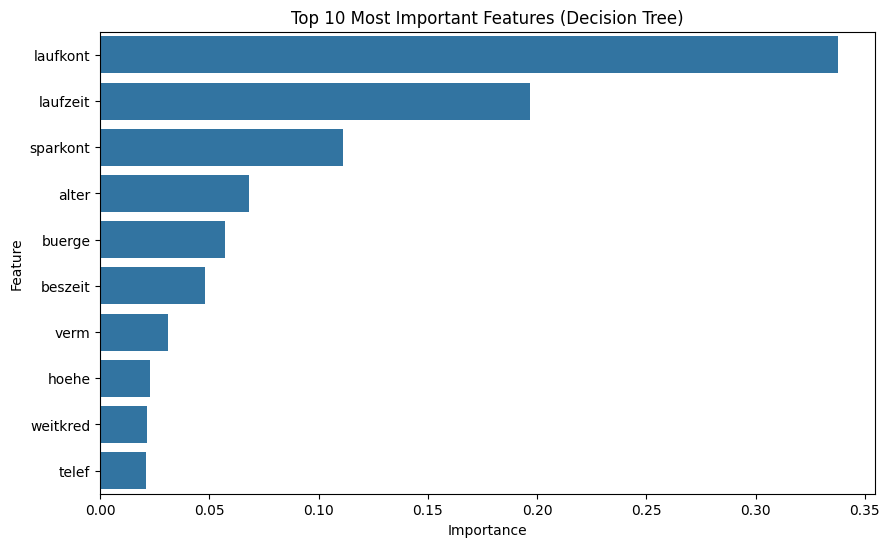

In [16]:
# Extract feature importance
importances = dt_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Most Important Features (Decision Tree)')
plt.show()